# IY029: MLP Pairwise Baseline — Same/Different Task

Diagnostic notebook: trains a simple MLP directly on flattened raw trajectory pairs for the same pairwise same/different task used in `IY029_transformer_pairwise.ipynb`.

## Architecture
- **Input**: full flattened pair `[x1_full | x2_full]` — each half is the full trajectory segment (no crop)
- **Network**: Linear → BN → ReLU → Dropout, three hidden layers (512, 256, 64)
- **Head**: Linear → 1 logit, BCE loss
- Matches IY025 raw SVM which also uses the full trajectory

## Datasets
Same IY011/IY014 static loaders (train/val/test splits).

In [1]:
import sys
sys.path.insert(0, '../../src')

import json
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

from dataloaders import load_loader_from_disk

plt.rcParams.update({
    'font.family': 'sans-serif', 'axes.labelsize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 10, 'axes.titlesize': 14,
})

EXP_DIR    = Path('../..')
IY011_ROOT = EXP_DIR / 'experiments/EXP-25-IY011'
IY014_ROOT = EXP_DIR / 'experiments/EXP-26-IY014'
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAMPLE_LEN = 500

BATCH_SIZE = 256
N_EPOCHS   = 100
LR         = 1e-3

print(f'Device: {DEVICE}')

DATASET_CONFIGS = [
    {
        'name':        'Baseline',
        'iy011_train': IY011_ROOT / 'data'                / 'IY011_static_train.pt',
        'iy011_val':   IY011_ROOT / 'data'                / 'IY011_static_val.pt',
        'iy011_test':  IY011_ROOT / 'data'                / 'IY011_static_test.pt',
        'iy014_train': IY014_ROOT / 'data'                / 'IY014_static_train.pt',
        'iy014_val':   IY014_ROOT / 'data'                / 'IY014_static_val.pt',
        'iy014_test':  IY014_ROOT / 'data'                / 'IY014_static_test.pt',
    },
    {
        'name':        'Mu',
        'iy011_train': IY011_ROOT / 'data_mu_variation'   / 'IY011_static_train.pt',
        'iy011_val':   IY011_ROOT / 'data_mu_variation'   / 'IY011_static_val.pt',
        'iy011_test':  IY011_ROOT / 'data_mu_variation'   / 'IY011_static_test.pt',
        'iy014_train': IY011_ROOT / 'data_mu_variation'   / 'IY014_static_train.pt',
        'iy014_val':   IY011_ROOT / 'data_mu_variation'   / 'IY014_static_val.pt',
        'iy014_test':  IY011_ROOT / 'data_mu_variation'   / 'IY014_static_test.pt',
    },
    {
        'name':        'CV',
        'iy011_train': IY011_ROOT / 'data_cv_variation'   / 'IY011_static_train.pt',
        'iy011_val':   IY011_ROOT / 'data_cv_variation'   / 'IY011_static_val.pt',
        'iy011_test':  IY011_ROOT / 'data_cv_variation'   / 'IY011_static_test.pt',
        'iy014_train': IY014_ROOT / 'data_cv_variation'   / 'IY014_static_train.pt',
        'iy014_val':   IY014_ROOT / 'data_cv_variation'   / 'IY014_static_val.pt',
        'iy014_test':  IY014_ROOT / 'data_cv_variation'   / 'IY014_static_test.pt',
    },
    {
        'name':        'T_ac',
        'iy011_train': IY011_ROOT / 'data_t_ac_variation' / 'IY011_static_train.pt',
        'iy011_val':   IY011_ROOT / 'data_t_ac_variation' / 'IY011_static_val.pt',
        'iy011_test':  IY011_ROOT / 'data_t_ac_variation' / 'IY011_static_test.pt',
        'iy014_train': IY014_ROOT / 'data_t_ac_variation' / 'IY014_static_train.pt',
        'iy014_val':   IY014_ROOT / 'data_t_ac_variation' / 'IY014_static_val.pt',
        'iy014_test':  IY014_ROOT / 'data_t_ac_variation' / 'IY014_static_test.pt',
    },
]
DS_NAMES = [cfg['name'] for cfg in DATASET_CONFIGS]

Device: cuda


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Model & Helpers

In [2]:
class PairwiseMLP(nn.Module):
    """
    Simple MLP for pairwise same/different classification.
    Input: full flattened [x1 | x2] pair, shape (T,) where T = full concatenated length.
    """
    def __init__(self, input_dim, hidden_dims=(512, 256, 64), dropout=0.3):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)   # (B,)


def load_split(pt_path):
    """Load a .pt loader → (X_np, y_np) numpy arrays."""
    loader = load_loader_from_disk(pt_path, batch_size=2048)
    Xs, ys = [], []
    for X, y in loader:
        Xs.append(X.numpy()); ys.append(y.numpy().ravel())
    return np.concatenate(Xs), np.concatenate(ys).astype(np.float32)


def flatten_pairs(X_np):
    """Flatten the full concatenated pair → (N, T), matching IY025 raw SVM (no crop)."""
    half = X_np.shape[1] // 2
    x1 = X_np[:, :half,  0]   # (N, half)   — full first trajectory
    x2 = X_np[:, half:,  0]   # (N, T-half) — full second trajectory
    return np.concatenate([x1, x2], axis=1)   # (N, T)


def make_loader(X_flat, y, shuffle=True):
    ds = torch.utils.data.TensorDataset(
        torch.tensor(X_flat, dtype=torch.float32),
        torch.tensor(y,      dtype=torch.float32),
    )
    return torch.utils.data.DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = total = 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        preds = (torch.sigmoid(model(X)) > 0.5).float()
        correct += (preds == y).sum().item()
        total   += len(y)
    return correct / total


def train_and_eval(X_tr, y_tr, X_va, y_va, X_te, y_te, verbose=False):
    """Train a fresh PairwiseMLP and return (test_accuracy, loss_curve)."""
    input_dim = X_tr.shape[1]
    model  = PairwiseMLP(input_dim).to(DEVICE)
    optim  = torch.optim.Adam(model.parameters(), lr=LR)
    crit   = nn.BCEWithLogitsLoss()
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=N_EPOCHS)

    tr_loader = make_loader(X_tr, y_tr, shuffle=True)
    va_loader = make_loader(X_va, y_va, shuffle=False)
    te_loader = make_loader(X_te, y_te, shuffle=False)

    best_va, best_state = 0.0, None
    loss_curve = []

    for epoch in range(N_EPOCHS):
        model.train()
        epoch_loss = 0.0
        for X, y in tr_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            optim.zero_grad()
            loss = crit(model(X), y)
            loss.backward()
            optim.step()
            epoch_loss += loss.item()
        sched.step()
        loss_curve.append(epoch_loss / len(tr_loader))

        va_acc = evaluate(model, va_loader)
        if va_acc > best_va:
            best_va = va_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if verbose and (epoch + 1) % 20 == 0:
            print(f'  epoch {epoch+1:3d}  loss={loss_curve[-1]:.4f}  val={va_acc:.3f}')

    model.load_state_dict(best_state)
    return evaluate(model, te_loader), loss_curve

## Load Data, Flatten & Train

In [3]:
results     = {}   # {ds_name: {'iy011': acc, 'iy014': acc}}
loss_curves = {}

for cfg in DATASET_CONFIGS:
    name = cfg['name']
    results[name]     = {}
    loss_curves[name] = {}
    print(f'\n=== {name} ===')

    for fold in ('iy011', 'iy014'):
        print(f'  {fold}:', end=' ', flush=True)
        X_tr_raw, y_tr = load_split(cfg[f'{fold}_train'])
        X_va_raw, y_va = load_split(cfg[f'{fold}_val'])
        X_te_raw, y_te = load_split(cfg[f'{fold}_test'])

        # Flatten: [x1_crop | x2_crop] → (N, 2*SAMPLE_LEN)
        X_tr = flatten_pairs(X_tr_raw)
        X_va = flatten_pairs(X_va_raw)
        X_te = flatten_pairs(X_te_raw)

        acc, lc = train_and_eval(X_tr, y_tr, X_va, y_va, X_te, y_te, verbose=True)
        results[name][fold]     = acc
        loss_curves[name][fold] = lc
        print(f'test acc = {acc:.4f}')

print('\nDone.')


=== Baseline ===
  iy011: 📂 Loading static data from ../../experiments/EXP-25-IY011/data/IY011_static_train.pt...
📂 Loading static data from ../../experiments/EXP-25-IY011/data/IY011_static_val.pt...
📂 Loading static data from ../../experiments/EXP-25-IY011/data/IY011_static_test.pt...
  epoch  20  loss=0.1124  val=0.690
  epoch  40  loss=0.0293  val=0.690
  epoch  60  loss=0.0132  val=0.692
  epoch  80  loss=0.0060  val=0.683
  epoch 100  loss=0.0050  val=0.693
test acc = 0.7050
  iy014: 📂 Loading static data from ../../experiments/EXP-26-IY014/data/IY014_static_train.pt...
📂 Loading static data from ../../experiments/EXP-26-IY014/data/IY014_static_val.pt...
📂 Loading static data from ../../experiments/EXP-26-IY014/data/IY014_static_test.pt...
  epoch  20  loss=0.1023  val=0.785
  epoch  40  loss=0.0434  val=0.782
  epoch  60  loss=0.0180  val=0.790
  epoch  80  loss=0.0103  val=0.793
  epoch 100  loss=0.0106  val=0.787
test acc = 0.7867

=== Mu ===
  iy011: 📂 Loading static data fro

In [3]:
import json

_save_path = Path('IY029_mlp_pairwise_results.json')
if _save_path.exists():
    with open(_save_path) as _f:
        results = json.load(_f)
    print(f'Loaded existing {_save_path} (skipping overwrite)')
else:
    with open(_save_path, 'w') as _f:
        json.dump(
            {ds: {fold: float(results[ds][fold]) for fold in ('iy011', 'iy014')}
             for ds in DS_NAMES},
            _f, indent=2,
        )
    print(f'Saved {_save_path}')

Loaded existing IY029_mlp_pairwise_results.json (skipping overwrite)


## Results

In [6]:
palette   = sns.color_palette('colorblind')
ds_colors = {n: palette[i] for i, n in enumerate(DS_NAMES)}

NameError: name 'loss_curves' is not defined

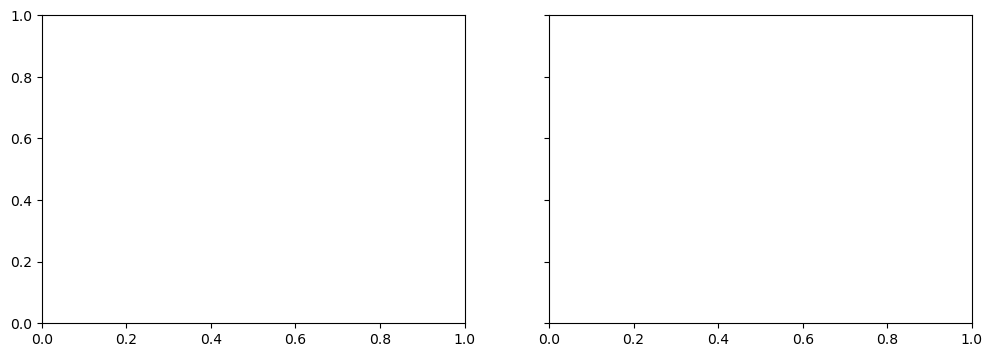

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, fold, fold_title in [
    (axes[0], 'iy011', 'IY011 (2-fold)'),
    (axes[1], 'iy014', 'IY014 (10-fold)'),
]:
    for name in DS_NAMES:
        ax.plot(loss_curves[name][fold], color=ds_colors[name], label=name, lw=1.5)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('BCE loss', fontsize=12)
    ax.set_title(fold_title, fontsize=13)
    ax.legend(fontsize=10)
fig.suptitle('Training loss curves — Pairwise MLP', fontsize=14)
plt.tight_layout()
plt.savefig('IY029_mlp_pairwise_loss.png', dpi=150, bbox_inches='tight')
plt.show()

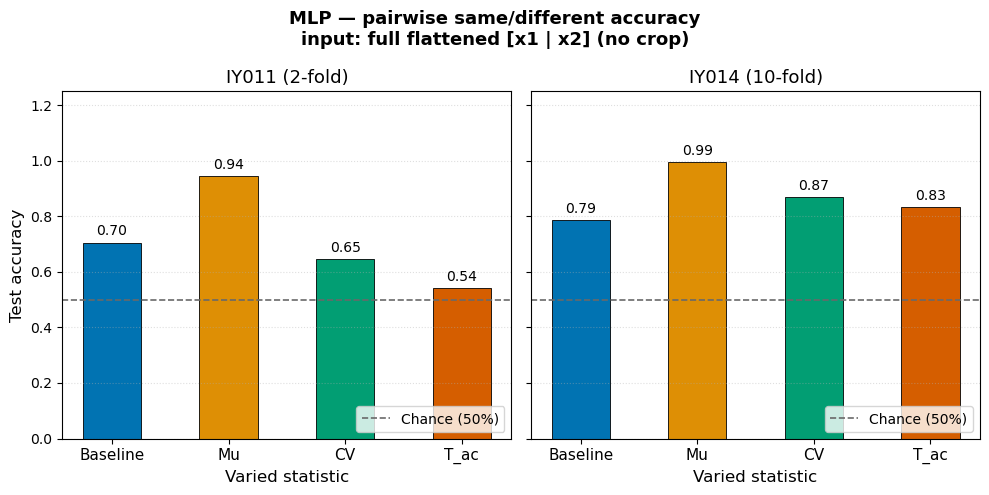

Saved IY029_mlp_pairwise_acc.png


In [7]:
colors = [palette[i] for i in range(len(DS_NAMES))]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
x     = np.arange(len(DS_NAMES))
width = 0.5

for ax, fold_key, fold_title in [
    (axes[0], 'iy011', 'IY011 (2-fold)'),
    (axes[1], 'iy014', 'IY014 (10-fold)'),
]:
    accs = [results[n][fold_key] for n in DS_NAMES]
    bars = ax.bar(x, accs, width, color=colors, edgecolor='black', linewidth=0.6)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=10)
    ax.axhline(0.5, color='dimgrey', linestyle='--', linewidth=1.2, label='Chance (50%)')
    ax.set_xticks(x)
    ax.set_xticklabels(DS_NAMES, fontsize=11)
    ax.set_xlabel('Varied statistic', fontsize=12)
    ax.set_ylim(0, 1.25)
    ax.set_title(fold_title, fontsize=13)
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(axis='y', linestyle=':', alpha=0.4)

axes[0].set_ylabel('Test accuracy', fontsize=12)
fig.suptitle('MLP — pairwise same/different accuracy\n'
             'input: full flattened [x1 | x2] (no crop)',
             fontsize=13, weight='bold')
plt.tight_layout()
plt.savefig('IY029_mlp_pairwise_acc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved IY029_mlp_pairwise_acc.png')

In [8]:
import pandas as pd
rows = []
for n in DS_NAMES:
    rows.append({
        'Dataset':         n,
        '2-fold (IY011)':  results[n]['iy011'],
        '10-fold (IY014)': results[n]['iy014'],
        'Mean':            np.mean([results[n]['iy011'], results[n]['iy014']]),
    })
df = pd.DataFrame(rows).set_index('Dataset')
pd.set_option('display.float_format', '{:.3f}'.format)
print(df.to_string())

          2-fold (IY011)  10-fold (IY014)  Mean
Dataset                                        
Baseline           0.705            0.787 0.746
Mu                 0.943            0.995 0.969
CV                 0.645            0.868 0.757
T_ac               0.540            0.833 0.687
